# Output integrity and physical consistency: `tas`, `tasmax`, `tasmin`, `pr`

Here we describe the quality-control checks we run on the downscaled outputs produced by our BCSD
pipeline for `CESM2-WACCM`, and we report their results directly against the production store. We
run three sets of checks. The first confirms that each output array is internally well formed,
following [issue #450](https://github.com/carbonplan/srm-downscaling/issues/450); the second
measures how often the three temperature variables violate the physical ordering
`tasmin ≤ tas ≤ tasmax`, following
[issue #448](https://github.com/carbonplan/srm-downscaling/issues/448); and the third checks the
physical constraints specific to precipitation, following
[issue #459](https://github.com/carbonplan/srm-downscaling/issues/459).

We group these checks together because they follow from the same property of the method. BCSD
bias-corrects and spatially disaggregates each variable separately, so `tas`, `tasmax`, `tasmin`,
and `pr` are processed without reference to one another. This is why the integrity checks are
necessary, because no later step re-imposes a joint constraint. It is also why the ordering among
the temperature variables can be distorted, and why precipitation must be checked for its own
physical validity, even when each variable is individually reasonable.

We run the checks against a single consolidated output store, pinned to the `v0.11.1` icechunk
branch. That branch is the regenerated production run: it carries `tas`, `tasmax`, `tasmin`, and
`pr`, and its regeneration trimmed the two coverage problems an earlier build showed (the `g6_1p5k`
pre-2035 `SSP245` bridge and the `ssp245` 2070 tail), so the time-bounds check now passes cleanly.
We evaluate both output families named in issue #450: the bias-corrected coarse outputs under
`debiased_coarse/…`, and the bias-corrected and spatially downscaled outputs in the top-level
scenario groups.

In [1]:
import functools
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import coiled
import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
import xarray as xr
import zarr
from dask_array.xarray import register

from srm.config import ClusterConfig, _icechunk_storage_for_path
from srm.qaqc import VAR_SPATIAL_RANGES
from srm.validation import resolve_member_time_bounds

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
# v0.11.1 is the regenerated production run: it carries tas/tasmax/tasmin/pr and includes the
# antimeridian NaN fix (#463). Its regeneration trimmed the g6_1p5k pre-2035 SSP245 bridge
# (predict_period_start: 2035) and the ssp245 2070 tail (#479 tightened the bound to 2069 for #476),
# so the two out-of-bounds cases that an earlier build (v0.11.0) showed no longer occur.
GCM = "CESM2-WACCM"
STORE_URI = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
BRANCH = "v0.11.1"
VARIABLES = ["tas", "tasmax", "tasmin", "pr"]
SPATIAL = ["lat", "lon"]

## Compute

The output store lives in S3 in `us-west-2`, and the checks read every cell of several dozen
multi-gigabyte arrays, so we run them on a distributed [Coiled](https://coiled.io) cluster in the
same region. Running in-region keeps the reads local and gives us the memory and parallelism the
whole-array reductions need; the settings below mirror `srm.config.ClusterConfig`, the same cluster
configuration the pipeline itself uses. We wrap the client with `frisky` so that progress stays
visible while the reductions run, and we raise `n_workers` for a larger domain or a faster
turnaround.

In [2]:
cfg = ClusterConfig(n_workers=[50, 50])
cluster = coiled.Cluster(
    name="srm-qaqc-output-checks",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=200,
)
client = hijack(cluster.get_client())
client

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/srm/srm-0.11.1.post1   │
│                    │ 0+g6835804a3.d20260726-py3-none-any.whl                 │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-07-26 04:28:09,813 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=50 maximum=50


<frisky.Client: scheduler="wss://cluster-xotor.dask.host/Pmisw6pf6aFMUs-O/frisky-comm?__frisky_dial_host=35.94.160.49" id="client-0">

## The output store layout

A single icechunk store holds every `(gcm, obs_dataset, subset)` result, versioned by branch
rather than by directory path. Within a branch, the data is organized into two families that share
the same `scenario / variable / member` layout but sit on different grids. The top-level
`historical`, `ssp245`, and `g6_1p5k` groups hold the final downscaled outputs on the fine ERA5
grid (721 × 1440), and the `debiased_coarse/…` subtree holds the intermediate bias-corrected coarse
outputs on the GCM grid (192 × 288).

We treat each `(family, scenario, variable, member)` path as a single leaf
and check the leaves independently. We keep members separate rather than combining them because
they do not all cover the same period; several `CESM2` `SSP245` members end in 2069 rather
than running to the end of the century.

In [3]:
repo = icechunk.Repository.open(_icechunk_storage_for_path(STORE_URI))
session = repo.readonly_session(BRANCH)

tree = xr.open_datatree(session.store, engine="zarr", chunks="auto")
tree

,Array,Chunk
Bytes,70.64 GiB,83.60 MiB
Shape,"(18263, 721, 1440)","(18263, 25, 48)"
Nodes,1,
,Array,Chunk
Bytes,70.64 GiB,83.60 MiB
Shape,"(18263, 721, 1440)","(18263, 25, 48)"
Nodes,1,
,Array,Chunk
Bytes,70.64 GiB,83.60 MiB
Shape,"(18263, 721, 1440)","(18263, 25, 48)"


In [4]:
# Top-level scenario groups hold the debiased + downscaled (fine-grid) outputs. The
# debiased_coarse/{scenario} subtree holds the bias-corrected coarse outputs -- same
# variable/member layout, one grid coarser. We check both families.
SCENARIO_LABELS = {"historical": "historical", "ssp245": "SSP245", "g6_1p5k": "G6-1.5K"}
GROUP_TO_SCENARIO = {
    **SCENARIO_LABELS,
    **{f"debiased_coarse/{g}": label for g, label in SCENARIO_LABELS.items()},
}


def group_leaves(group: str) -> dict[tuple[str, str, str], xr.DataArray]:
    """One lazy DataArray per (group, variable, member) present under tree[group]."""
    node = tree[group]
    return {
        (group, v, m): node[f"{v}/{m}"].dataset[v]
        for v in VARIABLES
        if v in node.children
        for m in node[v].children
    }


# One lazy DataArray per (scenario, variable, member) leaf, across both families.
leaves: dict[tuple[str, str, str], xr.DataArray] = {}
for group in GROUP_TO_SCENARIO:
    leaves.update(group_leaves(group))


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed by (scenario, variable, member)."""
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(
        ["scenario", "variable", "member"]
    )


print(f"{len(leaves)} (scenario, variable, member) leaves to check")

28 (scenario, variable, member) leaves to check


### A note on member coverage

The three temperature variables are not stored under a single, consistent set of member ids. `tas`
uses the ESM member labels (`r1i1p1f1`, and so on) for the historical period and numeric ids (`003`,
`008`, …) for the scenarios, while `tasmax` and `tasmin` are drawn from a corrected model run,
because of a known CMIP6 bug in those two variables; for the historical period, that corrected run
is stored as member `001` (see `srm.lineage`). This matters for Part 2, where a
`tasmin ≤ tas ≤ tasmax` comparison is only valid when all three variables are present under the same
stored member, a condition the historical period does not meet.

## Part 1: output integrity (issue #450)

Check whether every output array contains any `NaN`s, whether any two time slices are identical,
whether any timestep is entirely zero across the globe, whether its values fall within broadly
reasonable physical ranges, and whether it holds any data outside the input's time coverage. We
answer all five from one read of each leaf, because the costly part of the work is reading every
cell of several dozen multi-gigabyte arrays; we do it once, batching the leaves by scenario group so
that no single dask graph spans the whole store.

We define each reduction lazily and then compute them together, one scenario group at a time. The
individual checks then operate on the small per-leaf summaries that result, so they add little cost
beyond that first read.

In [5]:
def leaf_stats(da: xr.DataArray) -> xr.Dataset:
    """Lazy per-leaf reductions, fused into one pass over each array on compute."""
    return xr.Dataset(
        {
            "n_nan_cells": da.isnull().sum(),
            "min": da.min(),
            "max": da.max(),
            # Per-day spatial moments: a fingerprint reused by Checks 2, 3 and 5. Four independent
            # moments let Check 2 identify duplicate days from the fingerprint alone, with no
            # second read of the full array.
            "fingerprint": xr.concat(
                [da.min(SPATIAL), da.max(SPATIAL), da.mean(SPATIAL), da.std(SPATIAL)],
                dim=pd.Index(["min", "max", "mean", "std"], name="stat"),
            ),
        }
    )

### Check 1: no NaNs

These outputs should contain none, so we require every leaf to be entirely free of `NaN`s. A
non-zero count fails the check and points to a gap the pipeline should have filled rather than
shipped.

In [6]:
def check_no_nans(stats: dict) -> pd.DataFrame:
    """Total NaN count per leaf; pass = zero."""
    nan_df = table({k: {"n_nan_cells": int(s.n_nan_cells)} for k, s in stats.items()})
    nan_df["pass"] = nan_df.n_nan_cells == 0
    return nan_df

### Check 2: no duplicate time slices

Two identical days usually indicate a write error, such as a chunk written with the wrong date or a
step that ran twice. Comparing every pair of days directly would scale quadratically with the length
of the record, so we reduce each day to a compact fingerprint (its spatial minimum, maximum, mean,
and standard deviation) and group the days that share one. Four independent spatial moments make an
accidental collision between two genuinely different daily fields effectively impossible, so a
shared fingerprint is reported as a duplicate directly; we deliberately avoid a second,
per-collision read of the full array, which is both an extra pass over the data and a fragile ad-hoc
compute under the distributed scheduler.

In [7]:
def duplicate_pairs(fp: xr.DataArray) -> list[tuple[str, str]]:
    """Day-pairs sharing an identical (min, max, mean, std) spatial fingerprint.

    Four independent spatial moments make an accidental collision between two genuinely different
    daily fields effectively impossible, so a shared fingerprint is reported as a duplicate directly.
    We avoid a second, per-collision ``.equals()`` read of the full array: it is both an extra pass
    over the data and a fragile ad-hoc compute under the distributed scheduler.
    """
    arr = fp.transpose("time", "stat").values
    valid = ~np.isnan(arr).any(axis=1)
    times = fp.time.values[valid]

    _, inv = np.unique(arr[valid], axis=0, return_inverse=True)
    groups: dict[int, list[np.datetime64]] = {}
    for t, g in zip(times, inv):
        groups.setdefault(int(g), []).append(t)

    def fmt(t: np.datetime64) -> str:
        return str(np.datetime_as_string(t, unit="D"))

    return [(fmt(g[0]), fmt(t)) for g in groups.values() if len(g) > 1 for t in g[1:]]


def check_no_duplicates(stats: dict) -> pd.DataFrame:
    dup_df = table(
        {k: {"duplicate_pairs": duplicate_pairs(s.fingerprint)} for k, s in stats.items()}
    )
    dup_df["pass"] = dup_df.duplicate_pairs.str.len() == 0
    return dup_df

### Check 3: reasonable ranges

We apply the same wide sanity bounds used for the input data in
[#316](https://github.com/carbonplan/srm-downscaling/issues/316). Temperatures should fall within a
broad envelope in Kelvin, and a value well outside it is more often a unit error than genuine weather. We test each leaf's global minimum and maximum against
`VAR_SPATIAL_RANGES` from `srm.qaqc`, and we separately flag any day whose spatial extreme exceeds
the outlandish thresholds of 65 °C or −100 °C. We report the flagged days for inspection rather than
failing the leaf on them, because a single implausible cell is worth seeing but does not by itself
invalidate an array.

These bounds are global, so they say nothing about a value that is globally ordinary yet locally
impossible. A 25 °C day in Antarctic winter passes here. The
[plausible-value check](plausible-value-check.ipynb) notebook is the location- and season-aware
complement to this check: it builds a per-cell, per-day-of-year envelope from the observed ERA5
record plus the coarse model's modeled change, and reports how far each leaf strays outside it.

In [8]:
TEMP_VARS = {"tas", "tasmax", "tasmin"}
HOT_K = 65 + 273.15  # outlandishly_high_temp threshold (srm.qaqc)
COLD_K = -100 + 273.15  # outlandishly_low_temp threshold (srm.qaqc)


def irregular_days(v: str, fp: xr.DataArray) -> list[tuple[str, float]]:
    """(date, K) for days whose spatial max/min breaches the outlandish temp thresholds."""
    if v not in TEMP_VARS:
        return []
    smax = fp.sel(stat="max")
    smin = fp.sel(stat="min")
    bad = ((smax > HOT_K) | (smin < COLD_K)).values
    times = fp.time.values[bad]
    vals = smax.where(smax > HOT_K, smin).values[bad]  # report whichever extreme tripped
    return [(str(t)[:10], round(float(x), 1)) for t, x in zip(times, vals)]


def check_reasonable_ranges(stats: dict) -> pd.DataFrame:
    range_df = table(
        {
            k: {
                "min": float(s["min"]),
                "max": float(s["max"]),
                "irregular_days": irregular_days(k[1], s["fingerprint"]),
            }
            for k, s in stats.items()
        }
    )
    range_df["pass"] = [
        VAR_SPATIAL_RANGES[v]["min"][0] <= mn <= VAR_SPATIAL_RANGES[v]["min"][1]
        and VAR_SPATIAL_RANGES[v]["max"][0] <= mx <= VAR_SPATIAL_RANGES[v]["max"][1]
        for (s, v, m), mn, mx in zip(range_df.index, range_df["min"], range_df["max"])
    ]
    range_df["n_irregular_days"] = range_df.irregular_days.str.len()
    return range_df

### Check 4: within input time bounds

Downscaled output should not extend beyond the input it was derived from; if the `SSP245` forcing
ends in 2069, downscaled data running to 2070 would be invented. We compare each leaf's first and
last timestamps against the member's raw input bounds from `resolve_member_time_bounds` and fail any
leaf that starts before, or ends after, those bounds, with no exemptions.

Enforced strictly, this check passes everywhere on `v0.11.1`. An earlier build (`v0.11.0`) failed it
in two places, and the store regeneration cleared both: the `g6_1p5k` leaves no longer begin in 2015
before their 2035 SAI start, because the pre-2035 `SSP245` bridge is now trimmed from the output
(`predict_period_start: 2035`), and the `ssp245` members no longer run to 2070, because
[#479](https://github.com/carbonplan/srm-downscaling/pull/479) tightened the bound to 2069
(addressing #476). We keep the `bridged_pre_sai` and `stale_end_tail` sentinels as regression
guards, and on `v0.11.1` both stay empty.

In [9]:
def check_time_bounds(leaves: dict) -> pd.DataFrame:
    bounds_df = table(
        {
            (s, v, m): {
                "actual_start": str(da.time.values[0])[:10],
                "actual_end": str(da.time.values[-1])[:10],
                "n_time": da.sizes["time"],
                "expected": resolve_member_time_bounds(GCM, GROUP_TO_SCENARIO[s], m),
            }
            for (s, v, m), da in leaves.items()
        }
    )
    expected_start = bounds_df.expected.str[0].fillna("0000-01-01")  # no known bounds -> pass
    expected_end = bounds_df.expected.str[1].fillna("9999-12-31")
    is_sai = bounds_df.index.get_level_values("scenario").str.upper().str.contains("G6|SAI")
    starts_before_raw = bounds_df.actual_start < expected_start
    ends_after_raw = bounds_df.actual_end > expected_end
    # Enforce the raw-input bounds strictly, with no exemptions. On v0.11.1 every leaf passes; the
    # two sentinels below stay empty and remain as regression guards. They flagged v0.11.0, which
    # predated the store regeneration:
    #  - bridged_pre_sai (start): SAI output began 2015, before its raw 2035 start, when the
    #    2015-2035 gap was SSP245 bridged into the output (now trimmed, predict_period_start=2035).
    #  - stale_end_tail (end): output ran past the member's end bound -- the ssp245 007-010 leaves
    #    reached 2070, one year past the 2069 bound that #479 tightened (for #476).
    bounds_df["bridged_pre_sai"] = is_sai & starts_before_raw
    bounds_df["stale_end_tail"] = ends_after_raw
    bounds_df["pass"] = ~starts_before_raw & ~ends_after_raw
    return bounds_df

### Check 5: no all-zero timesteps

No physical field should ever be identically zero across the entire globe on a given day: a day of
0 K everywhere, or of zero precipitation, solar radiation, or humidity at every cell, is not weather
but a write or masking error (issue #425). We reuse the spatial minimum and maximum from the per-day
fingerprint of Check 2, and flag any day whose minimum and maximum are both exactly zero, which can
only happen when every cell is zero. The check applies to all variables, including precipitation:
although `pr` is legitimately zero at many individual cells, an entire global field of zero on a
single day never occurs in a correct dataset.

In [10]:
def all_zero_days(fp: xr.DataArray) -> list[str]:
    """Dates whose entire spatial field is exactly 0 (spatial min and max both 0) -- see #425."""
    smin = fp.sel(stat="min")
    smax = fp.sel(stat="max")
    bad = ((smin == 0) & (smax == 0)).values
    return [str(t)[:10] for t in fp.time.values[bad]]


def check_no_all_zero(stats: dict) -> pd.DataFrame:
    """Per-leaf list of all-zero global days; pass = none."""
    zero_df = table(
        {k: {"all_zero_days": all_zero_days(s["fingerprint"])} for k, s in stats.items()}
    )
    zero_df["pass"] = zero_df.all_zero_days.str.len() == 0
    return zero_df

### Running the checks

We materialize the lazy per-leaf statistics one scenario group at a time, using several small
`dask.compute` calls rather than one graph spanning every leaf, and then run the five checks against
the collected summaries. We fold precipitation's Part-3 physical counts into these same per-group
reads, so each `pr` array is read only once, and the results still collapse into one pass/fail table
across all leaves.

In [11]:
%%time

# Per-leaf reductions, batched by scenario group so no single dask graph spans every leaf. Leaves in
# different groups are independent arrays, so batching costs no extra reads. We also fold
# precipitation's Part-3 physical counts (negative / outlandish days per cell) into each group's
# read, so every pr array is read exactly once here rather than again in Part 3.
PR_OUTLANDISH = 2000 / 86400  # 2000 mm/day in kg m-2 s-1 (~0.02315); largest recorded ~1825 mm/day


def pr_physical(da: xr.DataArray) -> xr.Dataset:
    """Per-cell day counts for the Part-3 precip checks, folded into the Part-1 read."""
    return xr.Dataset(
        {
            "neg_days": (da < 0).sum("time"),  # non-negativity: expected 0 everywhere
            "high_days": (da > PR_OUTLANDISH).sum("time"),  # outlandish daily total
        },
        attrs={"n_time": da.sizes["time"]},
    )


def compute_with_retry(*collections, attempts=3, label=""):
    """dask.compute with retries so a transient scheduler glitch does not abort the whole run."""
    import time

    for attempt in range(1, attempts + 1):
        try:
            return dask.compute(*collections)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}")
            time.sleep(5)


# Compute each scenario group independently: a transient failure retries, and a group that still
# fails is recorded and skipped so the rest of the notebook still runs on what did compute.
stats: dict = {}
pr_phys: dict = {}
failed_groups: list[str] = []
for group in GROUP_TO_SCENARIO:
    g_leaves = {k: da for k, da in leaves.items() if k[0] == group}
    if not g_leaves:
        continue
    try:
        s, p = compute_with_retry(
            {k: leaf_stats(da) for k, da in g_leaves.items()},
            {k: pr_physical(da) for k, da in g_leaves.items() if k[1] == "pr"},
            label=f"[{group}] ",
        )
    except Exception as exc:
        failed_groups.append(group)
        print(f"  {group}: FAILED after retries ({type(exc).__name__}); continuing with the rest")
        continue
    stats.update(s)
    pr_phys.update(p)
    print(f"  {group}: {len(s)} leaves computed")

if failed_groups:
    print(
        f"\n!! groups that did not compute: {failed_groups} -- rerun those before trusting results"
    )

# Every check runs on the leaves that actually computed, so a failed group is simply absent (with the
# warning above) rather than crashing the notebook. bounds only reads time coords, so restrict it too.
computed = {k: leaves[k] for k in stats}
nan_df = check_no_nans(stats)
dup_df = check_no_duplicates(stats)
zero_df = check_no_all_zero(stats)
range_df = check_reasonable_ranges(stats)
bounds_df = check_time_bounds(computed)

summary = pd.concat(
    {
        "no_nans": nan_df["pass"],
        "no_duplicate_timesteps": dup_df["pass"],
        "no_all_zero_days": zero_df["pass"],
        "reasonable_range": range_df["pass"],
        "n_irregular_days": range_df["n_irregular_days"],
        "within_input_time_bounds": bounds_df["pass"],
        "bridged_pre_sai": bounds_df["bridged_pre_sai"],  # regression sentinel (empty on v0.11.1)
        "stale_end_tail": bounds_df["stale_end_tail"],  # regression sentinel (empty on v0.11.1)
    },
    axis=1,
)
print(summary.to_string())

check_cols = [
    "no_nans",
    "no_duplicate_timesteps",
    "no_all_zero_days",
    "reasonable_range",
    "within_input_time_bounds",
]
print(f"\nAll checks pass across {len(summary)} leaves: {bool(summary[check_cols].all().all())}")

# On v0.11.1 there should be no within_input_time_bounds failures. The two sentinels below stay
# empty; should one ever fire it must still match a known case (regression guard, not a surprise).
tb_fail = ~summary["within_input_time_bounds"]
known = summary["bridged_pre_sai"] | summary["stale_end_tail"]
print(
    f"within_input_time_bounds failures: {int(tb_fail.sum())} "
    f"(g6 bridge: {int(summary['bridged_pre_sai'].sum())}, "
    f"stale end tail: {int(summary['stale_end_tail'].sum())}; "
    f"all known: {bool((tb_fail == known).all())})"
)
other_cols = ["no_nans", "no_duplicate_timesteps", "no_all_zero_days", "reasonable_range"]
print(f"All other checks pass on every leaf: {bool(summary[other_cols].all().all())}")

  historical: 4 leaves computed
  ssp245: 6 leaves computed
  g6_1p5k: 4 leaves computed
  debiased_coarse/historical: 4 leaves computed
  debiased_coarse/ssp245: 6 leaves computed
  debiased_coarse/g6_1p5k: 4 leaves computed
                                              no_nans  no_duplicate_timesteps  no_all_zero_days  reasonable_range  n_irregular_days  within_input_time_bounds  bridged_pre_sai  stale_end_tail
scenario                   variable member                                                                                                                                                    
historical                 tas      r3i1p1f1     True                    True              True              True                 0                      True            False           False
                           tasmax   001          True                    True              True              True                 0                      True            False           False
          

A clean store reports zero `NaN`s, no duplicated days, no all-zero global fields, and values within
range. Here every leaf is clean on those counts except the `g6_1p5k` `tas` and `pr` leaves, which
carry `NaN`s (a Check 1 failure, examined just below); the drill-down counts the leaves that carry
`NaN`s, surfaces any all-zero timesteps (Check 5 failures, issue #425), and lists any individual days
whose spatial extreme crossed the outlandish thresholds, shown for inspection rather than as
failures.

In [12]:
# Any leaf with NaNs fails Check 1; on the fixed data (v0.11.1) there should be none.
print(f"Leaves with any NaN: {int((nan_df.n_nan_cells > 0).sum())}")

# Any leaf with an all-zero global timestep fails Check 5 (#425); none expected.
zero_flagged = zero_df[~zero_df["pass"]]
if len(zero_flagged):
    print("\nAll-zero timesteps (Check 5 failure, #425):")
    for (s, v, m), row in zero_flagged.iterrows():
        print(f"  {s}/{v}/{m}: {len(row.all_zero_days)} days -- e.g. {row.all_zero_days[:5]}")
else:
    print("\nNo all-zero timesteps flagged.")

# Drill-down: dates + values for any leaf with implausible single-day spikes.
flagged = range_df[range_df.n_irregular_days > 0]
if len(flagged):
    print("\nIrregular days (report-only, spatial extreme past 65C / -100C):")
    for (s, v, m), row in flagged.iterrows():
        print(f"  {s}/{v}/{m}: {row.n_irregular_days} days")
        for date, k in row.irregular_days:
            print(f"    {date}  {k}K ({k - 273.15:.1f}C)")
else:
    print("\nNo irregular days flagged.")

Leaves with any NaN: 4

No all-zero timesteps flagged.

No irregular days flagged.


### The `g6_1p5k` `tas` and `pr` NaNs

Check 1 fails on exactly four leaves: the `g6_1p5k` `tas` and `pr` outputs for member `003`, once in
the downscaled family and once in `debiased_coarse`. The `NaN` cells are sporadic and shift from day
to day rather than forming a fixed land–sea mask, the `g6_1p5k` `tasmax` and `tasmin` leaves are
unaffected, and `v0.11.0` was `NaN`-free everywhere, so this is a regression the regeneration
introduced into those two variables specifically. We record it here and leave the fix to a
follow-up, because correcting it belongs in the pipeline and the store rather than in this read-only
check.

### Time coverage per leaf

The pass/fail table collapses two facts worth seeing directly, because both come up when reading the
checks. The table below lists each leaf's real first and last day, its length in timesteps
(`n_time`), the expected bounds from `resolve_member_time_bounds`, and the two out-of-bounds
sentinels.

Two things stand out. First, the leaves do not share one time axis: members end in different years
and carry different `n_time`, with `ssp245/…/008` ending in 2069 and `…/003` running to 2099. Each
leaf is stored at its own length rather than padded to the longest member, which is why
`check_no_nans` finds no manufactured `NaN`s on the missing years. Second, the two sentinels stay
empty on `v0.11.1`: the `g6_1p5k` leaves now start in 2035 rather than 2015 (`bridged_pre_sai`
clear), and no `ssp245` leaf runs past 2069 (`stale_end_tail` clear). Both were `v0.11.0` symptoms
that the store regeneration removed.

In [13]:
# Per-leaf time coverage: each leaf keeps its own real extent (no shared, padded axis). On v0.11.1
# both out-of-bounds sentinels are clear -- the g6 leaves start 2035 and no ssp245 leaf passes 2069;
# both were v0.11.0 symptoms removed by the store regeneration.
coverage_cols = [
    "actual_start",
    "actual_end",
    "n_time",
    "expected",
    "bridged_pre_sai",
    "stale_end_tail",
]
print(bounds_df[coverage_cols].to_string())

                                             actual_start  actual_end  n_time                  expected  bridged_pre_sai  stale_end_tail
scenario                   variable member                                                                                              
historical                 tas      r3i1p1f1   1978-01-01  2014-12-31   13514  (1850-01-01, 2015-12-31)            False           False
                           tasmax   001        1978-01-01  2014-12-31   13514  (1978-01-01, 2015-12-31)            False           False
                           tasmin   001        1978-01-01  2014-12-31   13514  (1978-01-01, 2015-12-31)            False           False
                           pr       r3i1p1f1   1978-01-01  2014-12-31   13514  (1850-01-01, 2015-12-31)            False           False
ssp245                     tas      003        2015-01-01  2099-12-31   31046  (2015-01-01, 2099-12-31)            False           False
                                    008  

## Part 2: temperature ordering consistency (issue #448)

A day's minimum temperature cannot exceed its mean, and its mean cannot exceed its maximum:
`tasmin ≤ tas ≤ tasmax`. BCSD can break this ordering because it debiases and downscales the three
variables separately, so the adjustments applied to `tas` need not keep it between an independently
adjusted `tasmin` and `tasmax`. Following issue #448, our goal here is to measure how often the
ordering is violated, not to correct it, with the one exception described below.

The three relationships do not carry the same expectation. `tasmax ≥ tasmin` is enforced by an
explicit post-processing step ([#331](https://github.com/carbonplan/srm-downscaling/issues/331)), so
it should hold everywhere, and any violation is a regression. `tasmax ≥ tas` and `tasmin ≤ tas` are
not guaranteed by any step, so we simply record where and how often they fail. We express each
violation as a per-cell count of affected days, and we map the two unguaranteed conditions,
following the spatial approach of PR #473.

### Assembling comparable triplets

A consistency comparison is only meaningful where `tas`, `tasmax`, and `tasmin` share a stored
member and a grid. We identify those cases automatically by intersecting the members available for
each variable within a family, which selects the scenario and member combinations that are complete
in `v0.11.1` for both the coarse and downscaled families. This step excludes the historical period
on its own, without our having to special-case it, because its `tas` and its `tasmax`/`tasmin` are
stored under different member ids, as described above. The three variables can cover slightly
different periods, so we inner-join them on `time` before comparing.

In [14]:
%%time


def temperature_triplets(leaves: dict) -> list[tuple[str, str]]:
    """(family/scenario group, member) paths that carry tas AND tasmax AND tasmin."""
    have: dict[tuple[str, str], set[str]] = {}
    for group, v, m in leaves:
        have.setdefault((group, m), set()).add(v)
    return sorted(gm for gm, vs in have.items() if TEMP_VARS <= vs)


def ordering_violations(group: str, member: str) -> xr.Dataset:
    """Per-cell count of days each temperature-ordering rule is broken, for one triplet.

    tas/tasmax/tasmin can cover different time spans within one member (e.g. tas may end a
    year earlier), so we inner-join on time before comparing.
    """
    node = tree[group]
    tas = node[f"tas/{member}"].dataset["tas"]
    tasmax = node[f"tasmax/{member}"].dataset["tasmax"]
    tasmin = node[f"tasmin/{member}"].dataset["tasmin"]
    tas, tasmax, tasmin = xr.align(tas, tasmax, tasmin, join="inner")
    return xr.Dataset(
        {
            "max_lt_min": (tasmax < tasmin).sum("time"),  # expected 0 (#331 post-processing)
            "max_lt_tas": (tasmax < tas).sum("time"),  # diagnostic (#448)
            "min_gt_tas": (tasmin > tas).sum("time"),  # diagnostic (#448)
        },
        attrs={"n_time": tas.sizes["time"]},
    )


triplets = temperature_triplets(leaves)
print("Checkable (group, member) triplets:")
for g, m in triplets:
    print(f"  {g}/{m}")

viol = compute_with_retry({gm: ordering_violations(*gm) for gm in triplets}, label="[part2] ")[0]

Checkable (group, member) triplets:
  debiased_coarse/g6_1p5k/003
  debiased_coarse/ssp245/008
  g6_1p5k/003
  ssp245/008
CPU times: user 271 ms, sys: 87.8 ms, total: 359 ms
Wall time: 17 s


### Violation frequencies

The table below summarizes each triplet. It reports the number of days on which `tasmax < tasmin`,
which we expect to be zero, and for the two unguaranteed relationships the number of grid cells
violated on at least one day, with the fraction of the domain they represent.

Read that fraction as spatial reach rather than severity. Because it counts a cell as soon as the
ordering fails on a single day out of the twenty to twenty-five thousand in the record, it saturates
toward one and says little about how often any given cell is actually affected. The maps that follow
show the per-cell frequency instead, which is the fairer picture of how severe the ordering problem
really is.

On `v0.11.1` the `g6_1p5k` and `ssp245` triplets sit on comparable footing: each draws all three
variables from a single member, and neither carries a bridged early period, because the regeneration
trims `g6_1p5k` to its 2035 SAI start. Any remaining difference between them is a downscaling effect
rather than the provenance artifact an earlier build showed, where `g6_1p5k` mixed different `SSP245`
members before 2035.

In [15]:
def consistency_summary(viol: dict) -> pd.DataFrame:
    rows = {}
    for (group, m), ds in viol.items():
        rows[(group, m)] = {
            "n_time": ds.attrs["n_time"],
            "days_max<min": int(ds.max_lt_min.sum()),  # #331 guarantee: should be 0
            "cells_max<tas": int((ds.max_lt_tas > 0).sum()),
            "frac_cells_max<tas": round(float((ds.max_lt_tas > 0).mean()), 5),
            "cells_min>tas": int((ds.min_gt_tas > 0).sum()),
            "frac_cells_min>tas": round(float((ds.min_gt_tas > 0).mean()), 5),
        }
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(["group", "member"])


consistency_df = consistency_summary(viol)
print(consistency_df.to_string())

n_regressions = int(consistency_df["days_max<min"].sum())
print(
    f"\ntasmax >= tasmin holds everywhere (#331): {n_regressions == 0} "
    f"(total offending days across triplets: {n_regressions})"
)

                                n_time  days_max<min  cells_max<tas  frac_cells_max<tas  cells_min>tas  frac_cells_min>tas
group                   member                                                                                            
debiased_coarse/g6_1p5k 003      18263             0          49512             0.89540          54341             0.98273
debiased_coarse/ssp245  008      20089             0          50808             0.91884          54528             0.98611
g6_1p5k                 003      18263             0         868966             0.83696         984118             0.94787
ssp245                  008      20089             0         900704             0.86753         992739             0.95617

tasmax >= tasmin holds everywhere (#331): True (total offending days across triplets: 0)


### Where the ordering breaks

For each triplet, we map the fraction of days on which `tasmax < tas` and on which `tasmin > tas`,
masking the cells that never violate the ordering so the affected areas stand out. The colour scale
is the per-cell frequency of violation, so a pale field means the ordering almost always holds and a
saturated one means it fails often.

The violations are largely an ocean and high-latitude phenomenon. Land interiors stay near-white, so
the ordering rarely flips there, while coherent bands line the coastal upwelling zones (Peru–Chile,
Namibia, California), the tropical Pacific, and the Southern Ocean, with a pronounced North Atlantic
and Arctic hotspot. These are physically organized patterns rather than scattered noise, and they
are the genuine signature of debiasing and downscaling the three variables independently. A map
invites disagreement about degree, so the next section measures the land, ocean, and high-latitude
split rather than leaving it to the eye. Because `v0.11.1` trims the `g6_1p5k` bridge, its maps now
resemble the single-member `ssp245` maps rather than sitting at the inflated, bridge-driven
frequencies an earlier build showed.

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


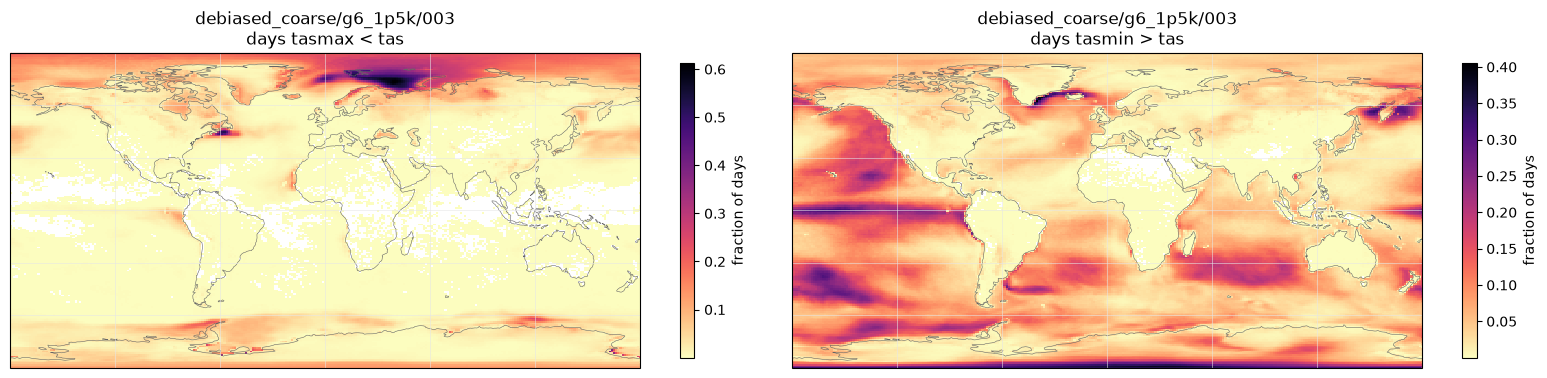

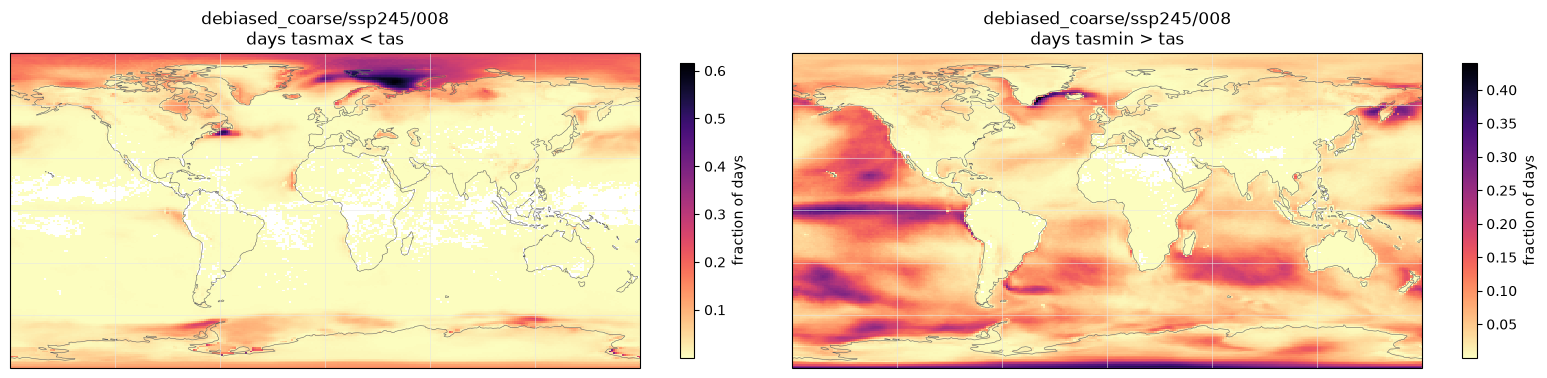

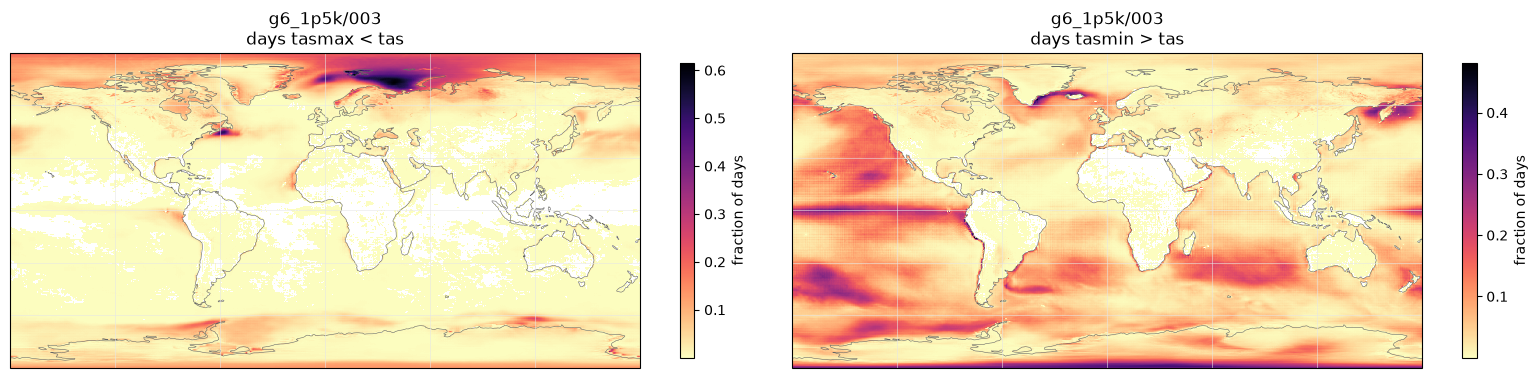

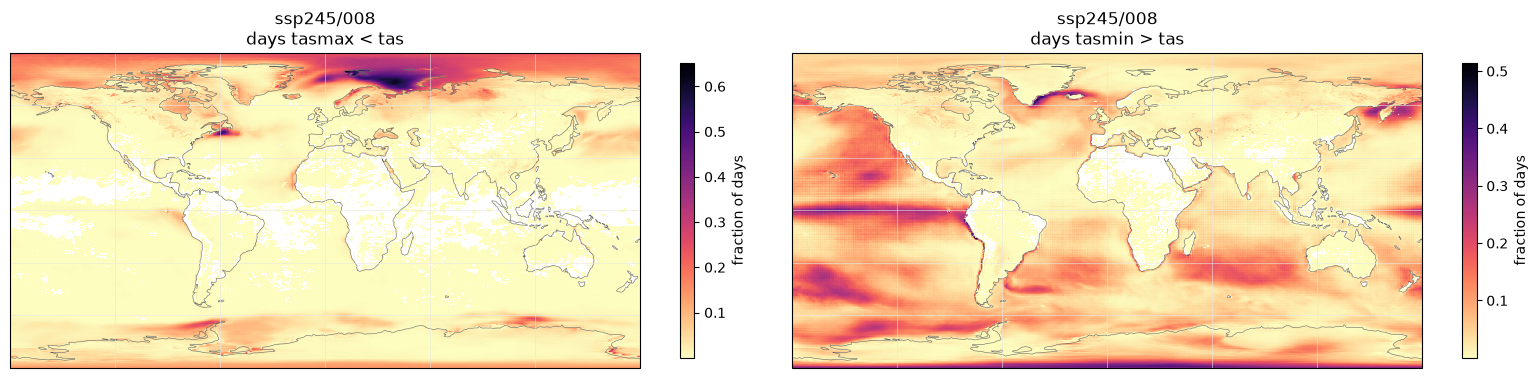

In [16]:
def plot_violation_maps(viol: dict) -> None:
    conds = [("max_lt_tas", "days tasmax < tas"), ("min_gt_tas", "days tasmin > tas")]
    for (group, m), ds in viol.items():
        n_time = ds.attrs["n_time"]
        fig, axes = plt.subplots(
            1, 2, figsize=(16, 4), subplot_kw={"projection": ccrs.PlateCarree()}
        )
        for ax, (cond, title) in zip(axes, conds):
            frac = (ds[cond] / n_time).where(ds[cond] > 0)
            frac.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap="magma_r",
                cbar_kwargs={"label": "fraction of days", "shrink": 0.8},
            )
            ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
            ax.gridlines(draw_labels=False, color="0.9", linewidth=0.4)
            ax.set_title(f"{group}/{m}\n{title}")
        plt.tight_layout()
        plt.show()


plot_violation_maps(viol)

### Land, ocean, and high latitudes

The maps above suggest that the ordering breaks mostly over ocean and at high latitudes, and this
section measures that instead of asserting it. For each triplet we recompute the same two diagnostic
conditions over five regions: the whole domain, land, ocean, land and ocean below 60° of latitude,
and everything poleward of 60°. The counts come from the per-cell day totals already in memory, so
the stratification costs no extra reads of the store.

Two choices matter for reading the table. Every statistic is **area-weighted by the cosine of
latitude**, because a 0.25° cell near the pole covers a small fraction of the area of one at the
equator, and an unweighted mean would inflate exactly the high-latitude signal being measured. The
land mask marks a cell as land when its centre falls inside the Natural Earth 50 m land polygons,
the same dataset cartopy draws the coastlines above from, so the mask and the outlines agree. It
deliberately does not reuse the pipeline's optional ocean mask, which rasterizes the GSHHS coastline
shipped in the input catalog: that geometry contains no Antarctica and would file the whole
continent under "ocean", and it rasterizes with `all_touched=True`, which files every coastal ocean
cell under "land", and those are precisely the upwelling cells that carry the violations. Testing
cell centres also returns the same land area fraction, 0.287, on the coarse and the fine grid, so
the two output families stay comparable.

The table reports two statistics per condition. `frac_area_ever_*` is the share of the region's area
that violates the ordering on at least one day, which saturates for the same reason the earlier
table's fractions do; `mean_freq_*` is the area-weighted mean per-cell frequency of violation, which
is the severity measure and the one to compare across regions. The `ocean:land` ratio printed below
the table is the headline: it is how many times more often a unit of ocean area breaks the ordering
than a unit of land area does.


In [17]:
# Land/ocean and high-latitude stratification of the Part-2 counts. This is pure post-processing of
# the per-cell day counts already in `viol`, so it triggers no further reads of the store.
_LAND_MASKS: dict[tuple[int, int], xr.DataArray] = {}


@functools.cache
def _land_polygons():
    """Union of the Natural Earth 50 m land polygons, cached for the session."""
    path = shpreader.natural_earth(resolution="50m", category="physical", name="land")
    return shapely.union_all(list(shpreader.Reader(path).geometries()))


def land_mask(template: xr.DataArray) -> xr.DataArray:
    """Boolean mask on template's grid, True where the cell centre falls on land.

    We test cell centres against Natural Earth, the dataset the coastlines on the maps above come
    from, rather than reusing the pipeline's BCSDPipeline._build_ocean_mask, for two reasons that
    both bear directly on this table. The GSHHS coastline that helper rasterizes (catalog
    "ocean-mask") carries no Antarctica, so it would file the whole continent under "ocean" and
    corrupt the high-latitude rows. It also rasterizes with all_touched=True, which files every
    coastal ocean cell under "land", and those are exactly the upwelling cells that carry the
    violations. Centre testing yields the same land area fraction (0.287) on the coarse and fine
    grids, which keeps the two families comparable. Cached per grid shape, since the families
    differ.
    """
    key = (template.sizes["lat"], template.sizes["lon"])
    if key not in _LAND_MASKS:
        lon, lat = np.meshgrid(template["lon"].values, template["lat"].values)
        _LAND_MASKS[key] = xr.DataArray(
            shapely.contains_xy(_land_polygons(), lon, lat),
            coords={"lat": template["lat"], "lon": template["lon"]},
            dims=("lat", "lon"),
        )
    return _LAND_MASKS[key]


def regions_for(land: xr.DataArray) -> dict[str, xr.DataArray]:
    """Boolean region selectors on the land mask's grid, in reporting order."""
    abslat = np.abs(land["lat"])
    everywhere = xr.ones_like(land)
    return {
        "global": everywhere,
        "land": land,
        "ocean": ~land,
        "land |lat|<60": land & (abslat < 60),
        "ocean |lat|<60": ~land & (abslat < 60),
        "|lat|>=60": everywhere & (abslat >= 60),
    }


CONDS = {"max<tas": "max_lt_tas", "min>tas": "min_gt_tas"}


def regional_consistency_summary(viol: dict) -> pd.DataFrame:
    """Violation statistics per triplet and region, area-weighted by cos(lat).

    Area weighting is what makes the regions comparable: unweighted, the 0.25-degree cells crowded
    near the poles would dominate every mean and overstate the high-latitude signal.
    """
    rows = {}
    for (group, member), ds in viol.items():
        counts = ds["max_lt_tas"]
        land = land_mask(counts)
        weights = np.cos(np.deg2rad(ds["lat"])).broadcast_like(counts)
        n_time = ds.attrs["n_time"]
        for name, sel in regions_for(land).items():
            w = weights.where(sel, 0.0)
            row = {"area_frac": round(float(w.sum() / weights.sum()), 4)}
            for label, cond in CONDS.items():
                ever = (ds[cond] > 0).astype("float32")
                freq = ds[cond] / n_time
                row[f"frac_area_ever_{label}"] = round(float(ever.weighted(w).mean(SPATIAL)), 5)
                row[f"mean_freq_{label}"] = round(float(freq.weighted(w).mean(SPATIAL)), 6)
            row["days_max<min"] = int(ds["max_lt_min"].where(sel, 0).sum())
            rows[(group, member, name)] = row
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(["group", "member", "region"])


regional_df = regional_consistency_summary(viol)
print(regional_df.to_string())

# The headline for the land-vs-ocean reading: how many times more often a unit of ocean area breaks
# the ordering than a unit of land area does. "land 0" means the ordering never broke over land.
print("\nocean:land ratio of mean violation frequency")
for group, member in viol:
    parts = []
    for label in CONDS:
        over_land = regional_df.loc[(group, member, "land"), f"mean_freq_{label}"]
        over_ocean = regional_df.loc[(group, member, "ocean"), f"mean_freq_{label}"]
        parts.append(f"{label}: {over_ocean / over_land:.1f}x" if over_land else f"{label}: land 0")
    print(f"  {group}/{member}  " + "   ".join(parts))

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


                                               area_frac  frac_area_ever_max<tas  mean_freq_max<tas  frac_area_ever_min>tas  mean_freq_min>tas  days_max<min
group                   member region                                                                                                                       
debiased_coarse/g6_1p5k 003    global             1.0000                 0.84175           0.012290                 0.97527           0.054909             0
                               land               0.2872                 0.84733           0.010217                 0.91878           0.010280             0
                               ocean              0.7128                 0.83950           0.013125                 0.99804           0.072894             0
                               land |lat|<60      0.2307                 0.80994           0.003744                 0.89900           0.003975             0
                               ocean |lat|<60     0.6381  

The two conditions behave differently, and the difference is the interesting part. `tasmin > tas` is
overwhelmingly an ocean effect: on the downscaled `ssp245/008` triplet it breaks on 6.5 % of days
per unit of ocean area against 0.84 % over land, a ratio of 7.8 to 1, and the other three triplets
sit between 7.1 and 7.4. `tasmax < tas` is only mildly ocean-favoring at 1.4 to 1, but it
concentrates toward the poles instead: above 60° of latitude it breaks on 6.3 % of days against
1.3 % for the globe. The high-latitude signal belongs to that condition specifically, since
`tasmin > tas` runs at 5.1 % poleward of 60° against 4.9 % globally, which is no real elevation at
all.

Land below 60° is the quietest region by a wide margin. Both conditions break on roughly 0.3 % of
days there, about one day in three hundred, against 0.5 % and 6.5 % for ocean at the same latitudes.
That is the number behind the impression the maps give, and it holds in the coarse family too, where
the ocean-to-land ratio for `tasmin > tas` is 7.1 to 1 on `g6_1p5k/003` and 7.4 to 1 on
`ssp245/008`.

The `frac_area_ever_*` columns stay high everywhere, between 0.62 and 1.00, which is the saturation
the earlier table warns about rather than a contradiction. Nearly every cell breaks the ordering on
some day out of twenty thousand; only a small share of days at any one land cell actually does.

## Part 3: precipitation physical constraints (issue #459)

Part 1 already checked precipitation for `NaN`s, duplicate days, range, and time bounds alongside
the temperature variables, because `pr` is one of the variables in the run. Precipitation's physical checks are
single-variable: values must never fall below zero, and no day may carry an outlandishly large
total. Both were counted per grid cell in the same Part-1 pass that read each `pr` array, so this
section only summarizes and maps the results, adding no further reads.

In [18]:
def pr_physical_summary(phys: dict) -> pd.DataFrame:
    """One row per pr leaf: negative and outlandish-high day/cell tallies."""
    rows = {}
    for (group, _v, m), ds in phys.items():
        rows[(group, m)] = {
            "n_time": ds.attrs["n_time"],
            "neg_cell_days": int(ds.neg_days.sum()),
            "cells_with_neg": int((ds.neg_days > 0).sum()),
            "frac_cells_neg": round(float((ds.neg_days > 0).mean()), 5),
            "high_cell_days": int(ds.high_days.sum()),
            "cells_with_high": int((ds.high_days > 0).sum()),
        }
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(["group", "member"])


pr_physical_df = pr_physical_summary(pr_phys)
print(pr_physical_df.to_string())

n_neg = int(pr_physical_df["neg_cell_days"].sum())
n_high = int(pr_physical_df["high_cell_days"].sum())
print(f"\nNon-negativity holds everywhere (pr >= 0): {n_neg == 0} (negative cell-days: {n_neg})")
print(f"No outlandish daily totals: {n_high == 0} (outlandish cell-days: {n_high})")

                                     n_time  neg_cell_days  cells_with_neg  frac_cells_neg  high_cell_days  cells_with_high
group                      member                                                                                          
historical                 r3i1p1f1   13514              0               0             0.0               0                0
ssp245                     003        31046              0               0             0.0               0                0
                           008        20089              0               0             0.0               0                0
g6_1p5k                    003        18263              0               0             0.0               0                0
debiased_coarse/historical r3i1p1f1   13514              0               0             0.0               0                0
debiased_coarse/ssp245     003        31046              0               0             0.0               0                0
        

In [19]:
def plot_negativity_maps(phys: dict) -> None:
    """Map the fraction of days pr < 0, for any leaf that ever goes negative."""
    plotted = False
    for (group, _v, m), ds in phys.items():
        if int((ds.neg_days > 0).sum()) == 0:
            continue
        plotted = True
        frac = (ds.neg_days / ds.attrs["n_time"]).where(ds.neg_days > 0)
        fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})
        frac.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="magma_r",
            cbar_kwargs={"label": "fraction of days pr < 0", "shrink": 0.8},
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax.gridlines(draw_labels=False, color="0.9", linewidth=0.4)
        ax.set_title(f"{group}/{m}\nnegative precipitation")
        plt.tight_layout()
        plt.show()
    if not plotted:
        print("No leaf has any negative precipitation — nothing to map.")


def pr_high_days(fp: xr.DataArray) -> list[tuple[str, float]]:
    """(date, kg m-2 s-1) for days whose spatial-max pr exceeds the outlandish threshold."""
    smax = fp.sel(stat="max")
    bad = (smax > PR_OUTLANDISH).values
    return [(str(t)[:10], float(x)) for t, x in zip(fp.time.values[bad], smax.values[bad])]


plot_negativity_maps(pr_phys)

# Report-only drill-down over the Part-1 fingerprints, restricted to pr leaves.
flagged = {k: pr_high_days(s.fingerprint) for k, s in stats.items() if k[1] == "pr"}
flagged = {k: days for k, days in flagged.items() if days}
if flagged:
    print("Outlandish precip days (report-only, spatial max > 2000 mm/day):")
    for (s, v, m), days in flagged.items():
        print(f"  {s}/{v}/{m}: {len(days)} days")
        for date, val in days:
            print(f"    {date}  {val:.3e} kg m-2 s-1 ({val * 86400:.0f} mm/day)")
else:
    print("No outlandish precip days flagged.")

No leaf has any negative precipitation — nothing to map.
No outlandish precip days flagged.


## Summary

Part 1 checks the integrity of every leaf for all four variables (`tas`, `tasmax`, `tasmin`, and
`pr`) on the regenerated `v0.11.1` store. Across the 28 leaves the duplicate, all-zero (issue #425),
reasonable-range, and time-bounds checks all pass, and the two out-of-bounds cases an earlier build
(`v0.11.0`) showed are gone: `g6_1p5k` now starts at its 2035 SAI year rather than carrying the
pre-2035 `SSP245` bridge, and no `ssp245` leaf runs past the 2069 bound that #479 tightened, so
Check 4 is clean and the `bridged_pre_sai` and `stale_end_tail` sentinels stay empty. Check 1,
however, fails on four leaves: the `g6_1p5k` `tas` and `pr` outputs for member `003`, in both the
downscaled and the `debiased_coarse` families, carry `NaN`s, while the `g6_1p5k` `tasmax` and
`tasmin` leaves and every other scenario are `NaN`-free. Those `NaN` cells are sporadic and vary
from day to day rather than tracing a fixed mask, and `v0.11.0` reported none anywhere, so this is a
regression the regeneration introduced into those two variables. We flag it here for a follow-up fix
rather than resolving it in this read-only notebook.

Part 2 measures the temperature ordering `tasmin ≤ tas ≤ tasmax`. The `#331` post-processing that
guarantees `tasmax ≥ tasmin` holds on every day of every triplet, while the two unguaranteed
relationships, `tasmax ≥ tas` and `tasmin ≤ tas`, do fail. They do not fail everywhere: the pattern
is a coherent ocean and high-latitude one, concentrated along the coastal upwelling zones, the
tropical Pacific, and a North Atlantic–Arctic hotspot.

Stratifying those counts by surface and latitude, area-weighted so that polar cells do not count for
more than their share of the globe, puts a number on that pattern. Over land below 60° of latitude
both conditions break on roughly 0.3 % of days, about one day in three hundred. Over ocean,
`tasmin > tas` breaks on 6.5 % of days, which is 7.8 times the land rate on the downscaled
`ssp245/008` triplet and between 7.1 and 7.8 times across all four triplets. `tasmax < tas` behaves
differently: its ocean-to-land ratio is only 1.4, but it concentrates poleward, breaking on 6.3 % of
days above 60° against 1.3 % for the globe as a whole. The ordering problem is therefore real but
regional, an open-ocean and high-latitude effect that is close to absent over land away from the
poles. Because `v0.11.1` trims the `g6_1p5k` bridge, the `g6_1p5k` and `ssp245` triplets now show
the same single-member signature at nearly identical violation frequencies, so the residual
violations are the genuine consequence of debiasing and downscaling the three variables
independently rather than the provenance artifact the earlier build displayed. Fully guaranteeing
the ordering would require a joint post-processing step, which is out of scope here, and we still
cannot check the historical period, whose `tas` and `tasmax`/`tasmin` are stored under different
member ids and never form a comparable triplet.

Part 3 adds the physical checks precipitation needs in place of temperature ordering. Precipitation
has no cross-variable relationship to enforce, so we verify its single-variable invariants: values
must never fall below zero, and no day may carry an outlandishly large total (above 2000 mm/day).
Both hold across every `pr` leaf, with zero negative and zero outlandish cell-days, so precipitation
is physically clean in `v0.11.1`, apart from the `NaN`s that Check 1 flags for the `g6_1p5k` `pr`
leaf.

In [20]:
cluster.shutdown()

2026-07-26 04:30:12,039 - distributed.deploy.adaptive - INFO - Adaptive scaling stopped: minimum=50 maximum=50. Reason: unknown
